In [1]:
import math
from collections.abc import Callable

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from jacinta.processor.evaluator import ZScoreEvaluator
from jacinta.processor.transmitter import Transmitter
from jacinta.utils.scheduler import ConstantScheduler

In [2]:
MIN_X, MAX_X = -10.0, 10.0
MIN_Y, MAX_Y = -10.0, 10.0
MIN_Z, MAX_Z = -10.0, 10.0
MIN_W, MAX_W = -1.0, 1.0

# hyperparameters
MEAN_EMA_RATE = 0.001
VAR_EMA_RATE = 0.001
BIAS_SCALE = 10.0
LEARNING_RATE = 0.001
HITS_RATE = 1000
MIN_WIDTH = 1
MAX_DEPTH = None
SEED = 42

# simulation parameters
N_STEPS = 20000
N_PLOTS = 5

In [3]:
def eval_function(
    function: Callable[[float, float, float], float], x: float, y: float, z: float
) -> float:
    """
    Safely evaluate a function for the given values.

    Args:
        function (Callable[[float, float, float], float]): The function to evaluate.
        x (float): The first value to evaluate the function at.
        y (float): The second value to evaluate the function at.
        z (float): The third value to evaluate the function at.

    Returns:
        float: The result of the function evaluation.
    """
    try:
        w = function(x, y, z)
        if not math.isfinite(w):
            w = math.nan
        w = max(min(w, MAX_W), MIN_W)
    except (ArithmeticError, ValueError):
        w = math.nan
    return w

In [4]:
def plot_function(
    ax: plt.Axes,
    function: Callable[[float, float, float], float],
    slice_ax: str,
    slice_val: float,
    n_points: int = 100,
    elev: float = 30.0,
    azim: float = 30.0,
    colorbar: bool = True,
) -> None:
    """
    Plot a slice of a function.

    Args:
        ax (plt.Axes): The axes to plot on.
        function (Callable[[float, float, float], float]): The function to plot.
        slice_axis (str): The axis to slice along.
        slice_value (float): The value of the sliced axis.
        n_points (int): The number of points to plot per dimension.
            Defaults to 100.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
        colorbar (bool): Whether to plot the color bar.
            Defaults to True.
    """
    # evaluate the function
    if slice_ax == "x":
        y_step = (MAX_Y - MIN_Y) / (n_points - 1)
        z_step = (MAX_Z - MIN_Z) / (n_points - 1)
        y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
        z_vals = [MIN_Z + idx * z_step for idx in range(n_points)]
        x_grid = [slice_val for z_val in z_vals for y_val in y_vals]
        y_grid = [y_val for z_val in z_vals for y_val in y_vals]
        z_grid = [z_val for z_val in z_vals for y_val in y_vals]
        w_grid = [
            eval_function(function, slice_val, y_val, z_val)
            for z_val in z_vals
            for y_val in y_vals
        ]
    elif slice_ax == "y":
        x_step = (MAX_X - MIN_X) / (n_points - 1)
        z_step = (MAX_Z - MIN_Z) / (n_points - 1)
        x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
        z_vals = [MIN_Z + idx * z_step for idx in range(n_points)]
        x_grid = [x_val for z_val in z_vals for x_val in x_vals]
        y_grid = [slice_val for z_val in z_vals for x_val in x_vals]
        z_grid = [z_val for z_val in z_vals for x_val in x_vals]
        w_grid = [
            eval_function(function, x_val, slice_val, z_val)
            for z_val in z_vals
            for x_val in x_vals
        ]
    elif slice_ax == "z":
        x_step = (MAX_X - MIN_X) / (n_points - 1)
        y_step = (MAX_Y - MIN_Y) / (n_points - 1)
        x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
        y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
        x_grid = [x_val for y_val in y_vals for x_val in x_vals]
        y_grid = [y_val for y_val in y_vals for x_val in x_vals]
        z_grid = [slice_val for y_val in y_vals for x_val in x_vals]
        w_grid = [
            eval_function(function, x_val, y_val, slice_val)
            for y_val in y_vals
            for x_val in x_vals
        ]
    # normalize the function values for the color map
    normalize = Normalize(vmin=MIN_W, vmax=MAX_W)
    colormap = colormaps["viridis"]
    # build the mesh triangles
    triangles = []
    for row in range(n_points - 1):
        for col in range(n_points - 1):
            # build the mesh cell
            top_left = row * n_points + col
            top_right = top_left + 1
            bottom_left = (row + 1) * n_points + col
            bottom_right = bottom_left + 1
            # split the cell into two triangles
            triangles.append([top_left, top_right, bottom_right])
            triangles.append([top_left, bottom_right, bottom_left])
    # get the average function value of each triangle
    w_vals = [sum(w_grid[idx] for idx in triangle) / 3 for triangle in triangles]
    # map each function value to a color
    facecolors = [colormap(normalize(w_val)) for w_val in w_vals]
    # plot the function
    surface = ax.plot_trisurf(
        x_grid,
        y_grid,
        z_grid,
        triangles=triangles,
        antialiased=False,
    )
    surface.set_facecolors(facecolors)
    if colorbar:
        # set the height and bottom of the color bar
        colorbar_height = 0.9
        colorbar_bottom = (1.0 - colorbar_height) / 2
        # plot the color bar
        scalar_mappable = ScalarMappable(norm=normalize, cmap=colormap)
        scalar_mappable.set_array([])
        colorbar_ax = ax.inset_axes([1.02, colorbar_bottom, 0.04, colorbar_height])
        colorbar = ax.figure.colorbar(scalar_mappable, cax=colorbar_ax)
        colorbar.set_label("w")
        colorbar.ax.yaxis.set_label_position("left")
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_zlim(MIN_Z, MAX_Z)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"Reward Function ({slice_ax}={slice_val}, elev={elev}, azim={azim})")
    ax.grid(visible=True)
    return

In [5]:
def get_leaves(
    transmitter: Transmitter, probability: float = 1.0, bias: float = 0.0
) -> list[tuple[Transmitter, float]]:
    """
    Get the transmitter leaves with their probability densities.

    Args:
        transmitter (Transmitter): The transmitter to get the leaves of.
        probability (float): The probability of the transmitter being selected.
            Defaults to 1.0.
        bias (float): The bias to apply to the log-weights.
            Defaults to 0.0.

    Returns:
        list[tuple[Transmitter, float]]: A list of tuples containing the transmitter
            leaves and their probability densities.
    """
    # check if the transmitter is a leaf
    if transmitter.is_leaf:
        x_lower, x_upper = transmitter.bounds[0]
        y_lower, y_upper = transmitter.bounds[1]
        z_lower, z_upper = transmitter.bounds[2]
        # compute the probability density of the leaf
        probability_density = probability / (
            (x_upper - x_lower) * (y_upper - y_lower) * (z_upper - z_lower)
        )
        leaves = [(transmitter, probability_density)]
    # otherwise, recursively get its leaves
    else:
        log_weights = [child.log_weight for child in transmitter.children]
        # bias the log-weights
        bias_scale = 1.0 + bias * transmitter.bias_scale_scheduler(transmitter.depth)
        log_weights = [log_weight * bias_scale for log_weight in log_weights]
        # stable log-weights with softmax
        max_log_weight = max(log_weights)
        weights = [math.exp(log_weight - max_log_weight) for log_weight in log_weights]
        # get the transmitter leaves
        leaves = []
        total_weight = sum(weights)
        for child, weight in zip(transmitter.children, weights, strict=True):
            # compute the probability of the child being selected
            child_probability = probability * weight / total_weight
            child_leaves = get_leaves(child, child_probability, bias)
            leaves.extend(child_leaves)
    return leaves

In [6]:
def plot_transmitter(
    ax: plt.Axes,
    transmitter: Transmitter,
    slice_ax: str,
    slice_val: float,
    bias: float = 0.0,
    elev: float = 30.0,
    azim: float = 30.0,
    colorbar: bool = True,
) -> None:
    """
    Plot a slice of the probability density function of a transmitter.

    Args:
        ax (plt.Axes): The axes to plot on.
        transmitter (Transmitter): The transmitter to plot.
        slice_ax (str): The axis to slice along.
        slice_val (float): The value of the sliced axis.
        bias (float): The bias to apply to the log-weights.
            Defaults to 0.0.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
        colorbar (bool): Whether to plot the color bar.
            Defaults to True.
    """
    # get the transmitter leaves
    leaves = get_leaves(transmitter, bias=bias)
    # get the probability density of each leaf
    probability_densities = [probability_density for _, probability_density in leaves]
    # normalize the probability densities for the color map
    max_density = max(probability_densities)
    if max_density == 0.0:
        max_density = 1.0
    normalize = Normalize(vmin=0.0, vmax=max_density)
    colormap = colormaps["RdYlGn"]
    # get the sliced leaves
    rectangles = []
    for leaf, probability_density in leaves:
        x_lower, x_upper = leaf.bounds[0]
        y_lower, y_upper = leaf.bounds[1]
        z_lower, z_upper = leaf.bounds[2]
        if slice_ax == "x":
            # skip leaves that do not intersect the slice
            if not x_lower <= slice_val < x_upper:
                continue
            # build the rectangular intersection of the leaf with the slice
            vertices = [
                (slice_val, y_lower, z_lower),
                (slice_val, y_upper, z_lower),
                (slice_val, y_upper, z_upper),
                (slice_val, y_lower, z_upper),
            ]
        elif slice_ax == "y":
            if not y_lower <= slice_val < y_upper:
                continue
            vertices = [
                (x_lower, slice_val, z_lower),
                (x_upper, slice_val, z_lower),
                (x_upper, slice_val, z_upper),
                (x_lower, slice_val, z_upper),
            ]
        elif slice_ax == "z":
            if not z_lower <= slice_val < z_upper:
                continue
            vertices = [
                (x_lower, y_lower, slice_val),
                (x_upper, y_lower, slice_val),
                (x_upper, y_upper, slice_val),
                (x_lower, y_upper, slice_val),
            ]
        color = colormap(normalize(probability_density))
        rectangles.append((vertices, color))
    # plot the transmitter
    faces = [vertices for vertices, _ in rectangles]
    facecolors = [color for _, color in rectangles]
    collection = Poly3DCollection(
        faces,
        facecolors=facecolors,
        edgecolors="black",
        antialiased=False,
    )
    ax.add_collection3d(collection)
    if colorbar:
        # set the height and bottom of the color bar
        colorbar_height = 0.9
        colorbar_bottom = (1.0 - colorbar_height) / 2
        # plot the color bar
        scalar_mappable = ScalarMappable(norm=normalize, cmap=colormap)
        scalar_mappable.set_array([])
        colorbar_ax = ax.inset_axes([1.02, colorbar_bottom, 0.04, colorbar_height])
        colorbar = ax.figure.colorbar(scalar_mappable, cax=colorbar_ax)
        colorbar.set_label("Probability Density")
        colorbar.ax.yaxis.set_label_position("left")
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_zlim(MIN_Z, MAX_Z)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(
        "Transmitter Probability Density Function\n"
        f"({slice_ax}={slice_val}, bias={bias}, elev={elev}, azim={azim})"
    )
    ax.grid(visible=True)
    return

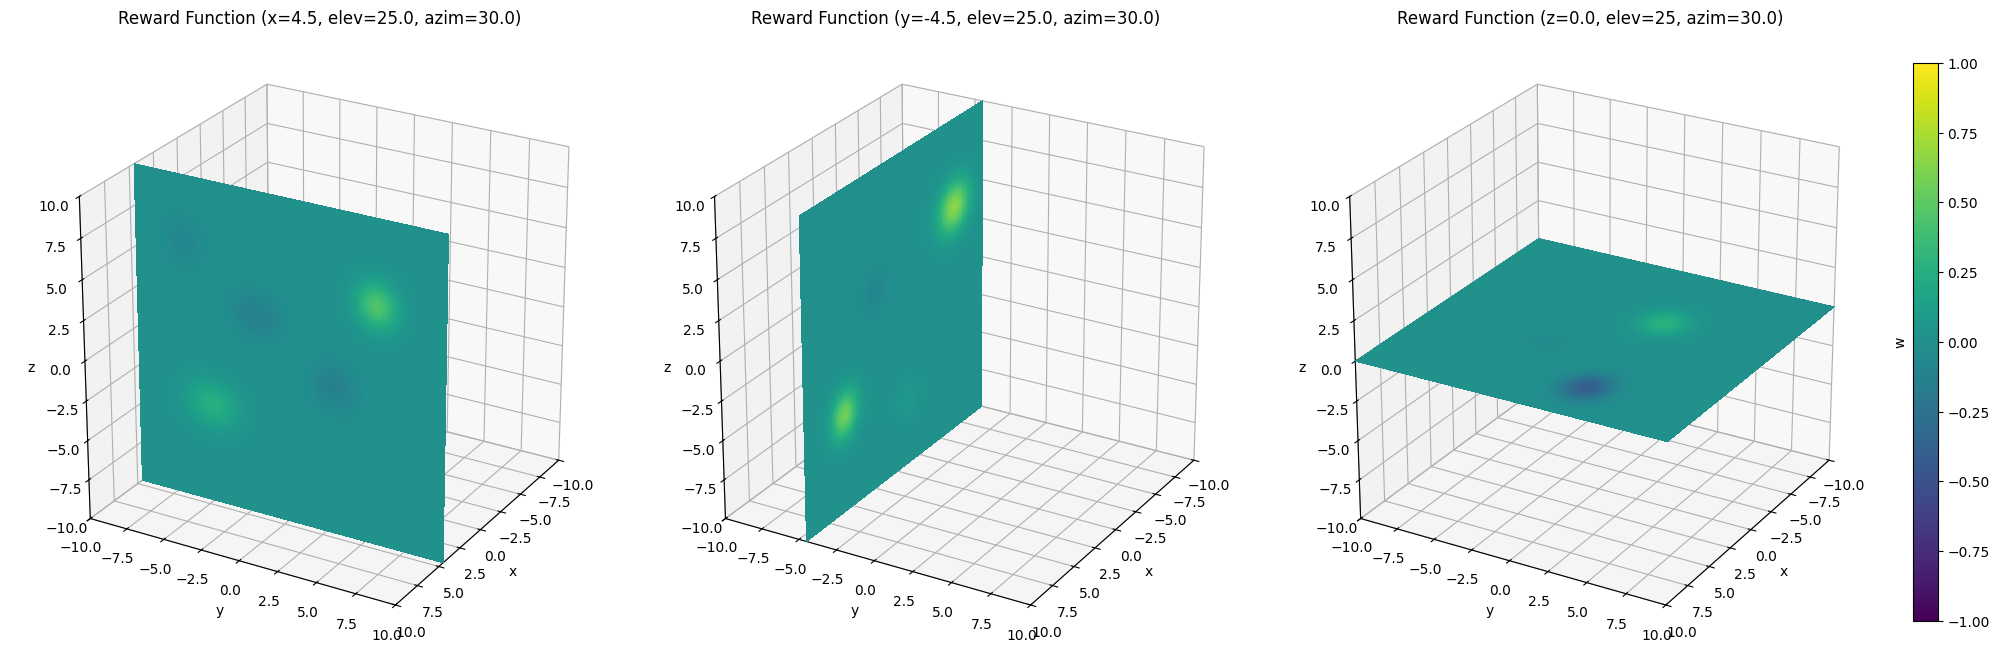

In [7]:
def reward_function(x: float, y: float, z: float) -> float:
    """
    Reward function.

    Args:
        x (float): The first value to evaluate the function at.
        y (float): The second value to evaluate the function at.
        z (float): The third value to evaluate the function at.

    Returns:
        float: The result of the function evaluation.
    """
    w = (
        0.9993
        * math.exp(
            -(((x + 3.0) / 1.7) ** 2 + ((y - 2.6) / 1.5) ** 2 + ((z - 1.8) / 1.6) ** 2)
        )
        + 0.7900
        * math.exp(
            -(((x + 6.6) / 1.8) ** 2 + ((y + 3.9) / 1.4) ** 2 + ((z - 4.5) / 1.6) ** 2)
        )
        + 0.6250
        * math.exp(
            -(((x - 5.8) / 1.4) ** 2 + ((y + 5.0) / 1.7) ** 2 + ((z + 3.8) / 1.5) ** 2)
        )
        + 0.4700
        * math.exp(
            -(((x - 4.2) / 1.6) ** 2 + ((y - 5.7) / 1.3) ** 2 + ((z - 4.8) / 1.4) ** 2)
        )
        + 0.3550
        * math.exp(
            -(((x + 1.2) / 1.4) ** 2 + ((y + 6.5) / 1.6) ** 2 + ((z + 5.8) / 1.3) ** 2)
        )
        + 0.2450
        * math.exp(
            -(((x - 7.0) / 1.3) ** 2 + ((y - 1.4) / 1.7) ** 2 + ((z + 6.2) / 1.5) ** 2)
        )
        - 0.9997
        * math.exp(
            -(((x - 2.4) / 1.5) ** 2 + ((y + 2.0) / 1.6) ** 2 + ((z - 2.5) / 1.4) ** 2)
        )
        - 0.7350
        * math.exp(
            -(((x + 5.4) / 1.4) ** 2 + ((y - 5.6) / 1.5) ** 2 + ((z + 3.6) / 1.7) ** 2)
        )
        - 0.5600
        * math.exp(
            -(((x - 6.5) / 1.7) ** 2 + ((y - 3.0) / 1.4) ** 2 + ((z + 0.8) / 1.5) ** 2)
        )
        - 0.4250
        * math.exp(
            -(((x + 6.8) / 1.6) ** 2 + ((y - 0.8) / 1.3) ** 2 + ((z + 5.6) / 1.4) ** 2)
        )
        - 0.3200
        * math.exp(
            -(((x - 0.4) / 1.3) ** 2 + ((y - 6.8) / 1.6) ** 2 + ((z - 6.4) / 1.5) ** 2)
        )
        - 0.2350
        * math.exp(
            -(((x - 3.0) / 1.5) ** 2 + ((y + 6.8) / 1.3) ** 2 + ((z - 6.0) / 1.6) ** 2)
        )
    )
    return w


# plot the reward function
fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
plot_function(
    ax[0], reward_function, slice_ax="x", slice_val=4.5, elev=25.0, colorbar=False
)
plot_function(
    ax[1], reward_function, slice_ax="y", slice_val=-4.5, elev=25.0, colorbar=False
)
plot_function(ax[2], reward_function, slice_ax="z", slice_val=0.0, elev=25)
# adjust the aspect ratio of each plot
for axis in ax:
    axis.set_box_aspect((1, 1, 1), zoom=0.95)
fig.tight_layout()
plt.show()

In [8]:
# initialize a 3D Transmitter
transmitter = Transmitter(
    bounds=((MIN_X, MAX_X), (MIN_Y, MAX_Y), (MIN_Z, MAX_Z)),
    evaluator=ZScoreEvaluator(MEAN_EMA_RATE, VAR_EMA_RATE),
    bias_scale_scheduler=ConstantScheduler(value=BIAS_SCALE),
    learning_rate_scheduler=ConstantScheduler(value=LEARNING_RATE),
    hits_rate_scheduler=ConstantScheduler(value=HITS_RATE),
    min_width=MIN_WIDTH,
    max_depth=MAX_DEPTH,
    seed=SEED,
)

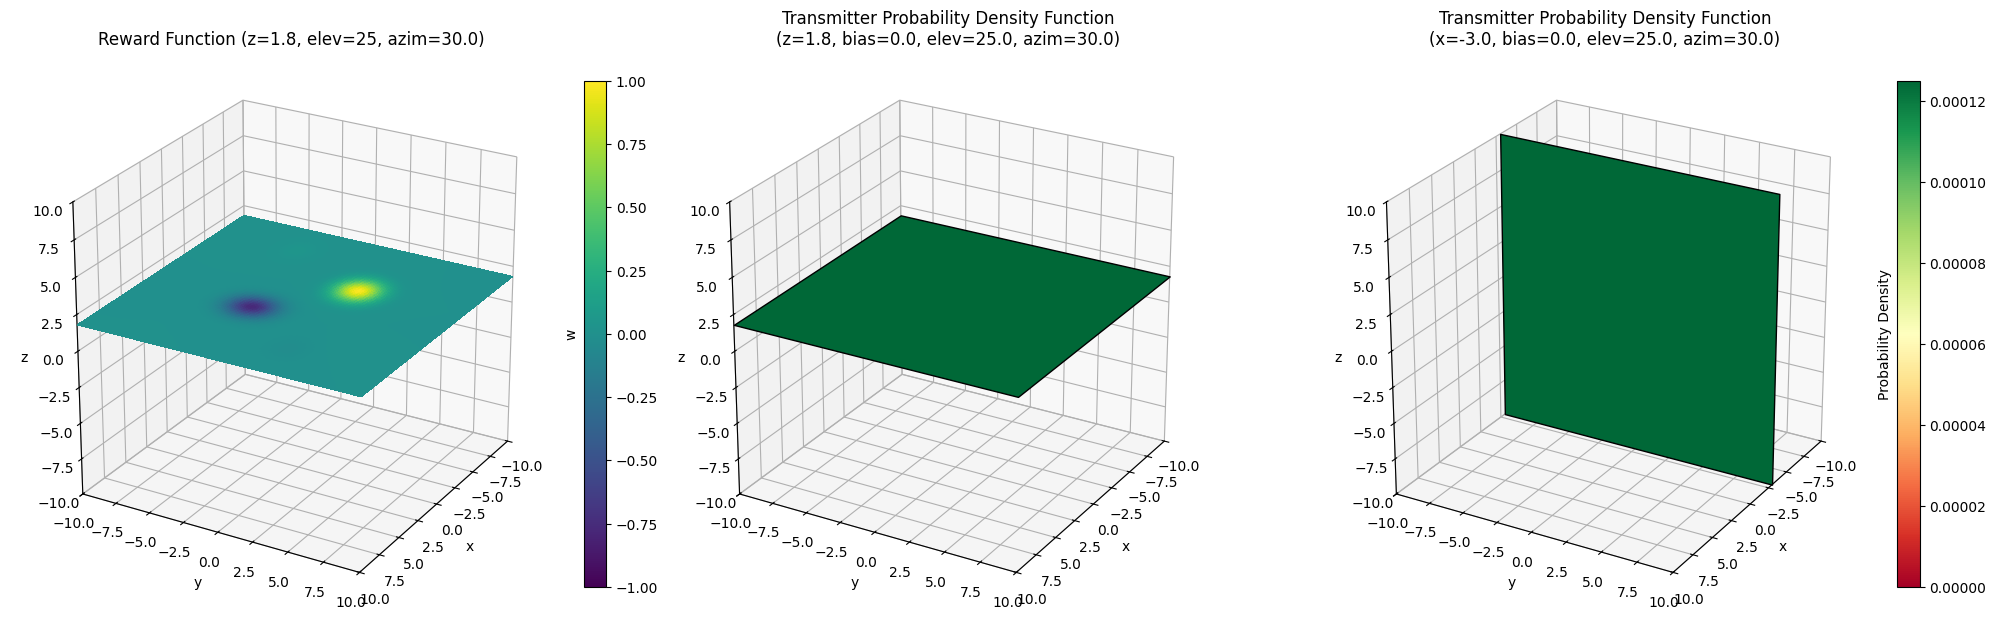

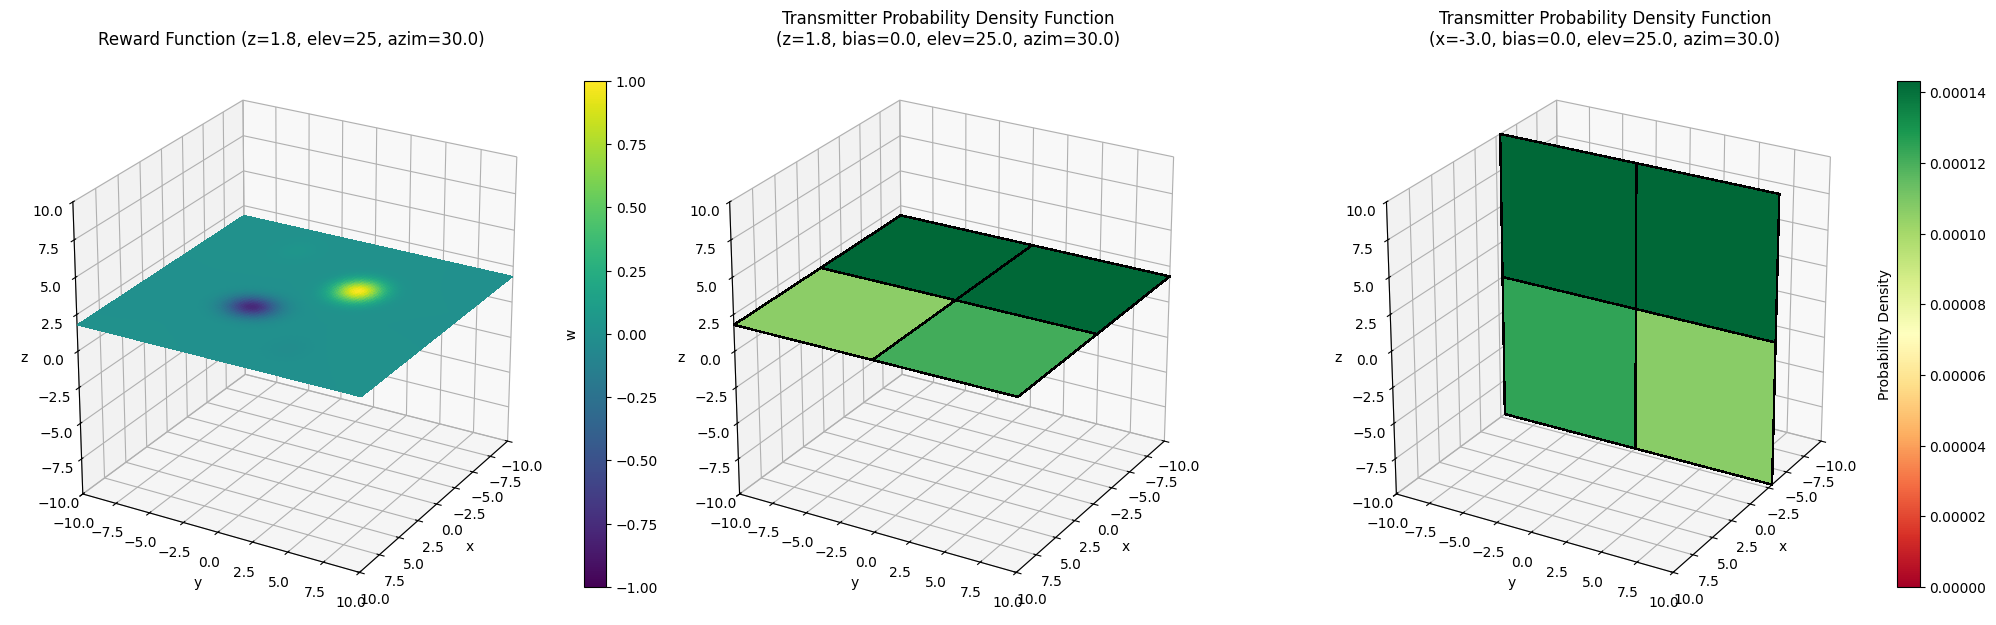

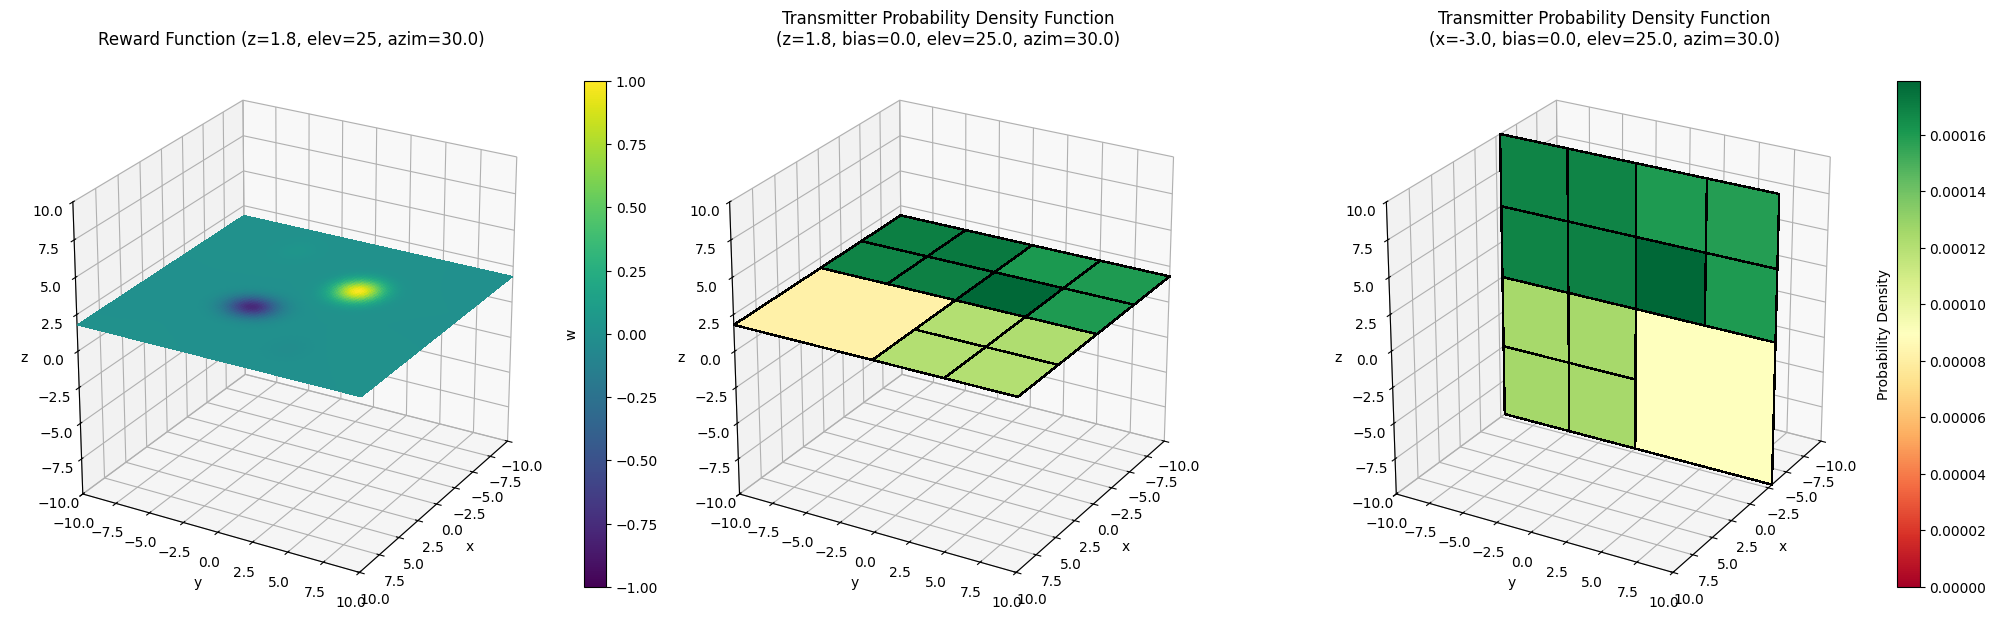

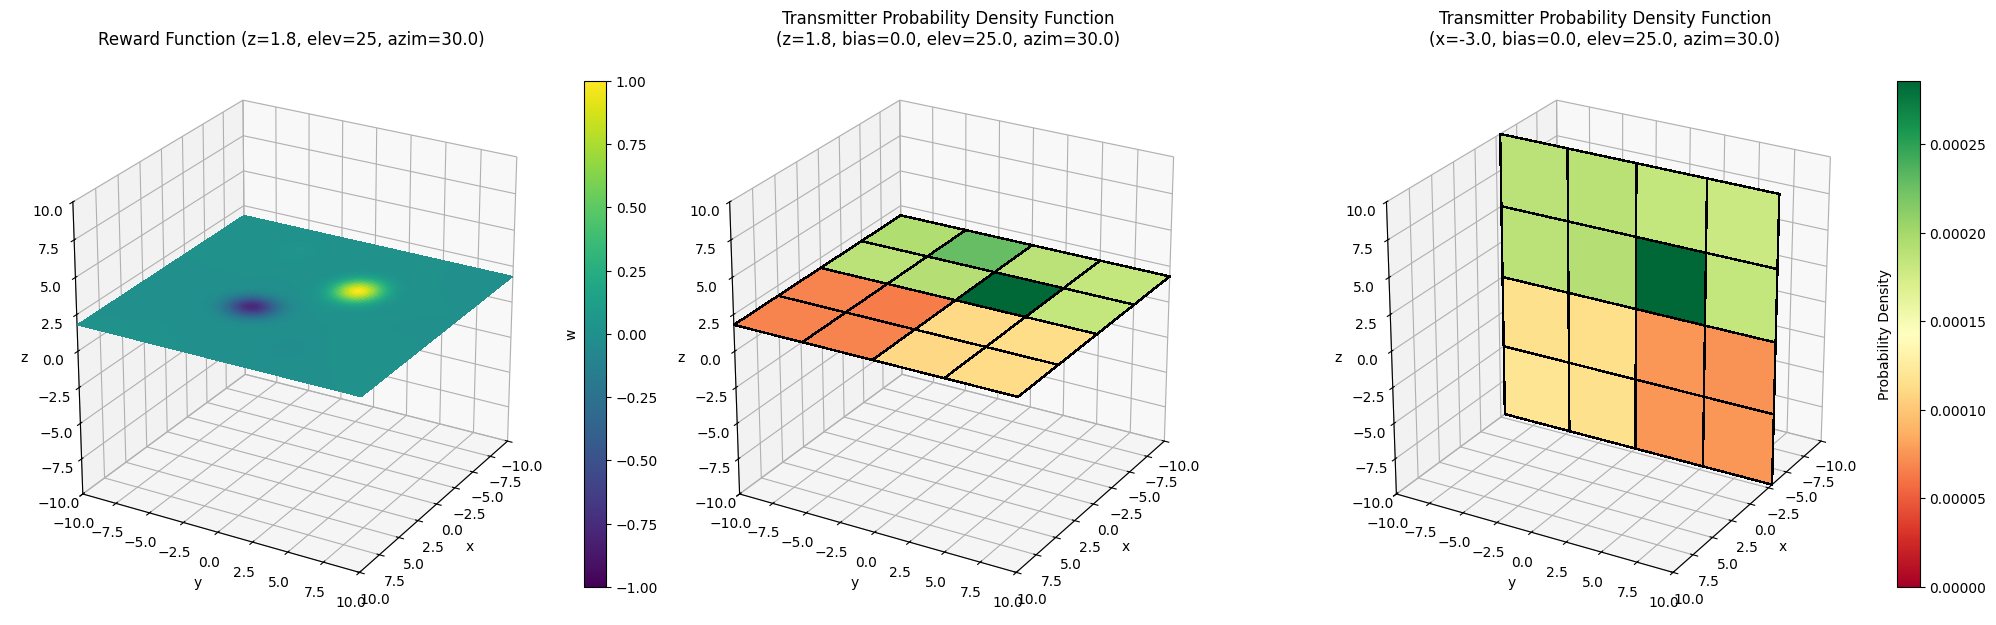

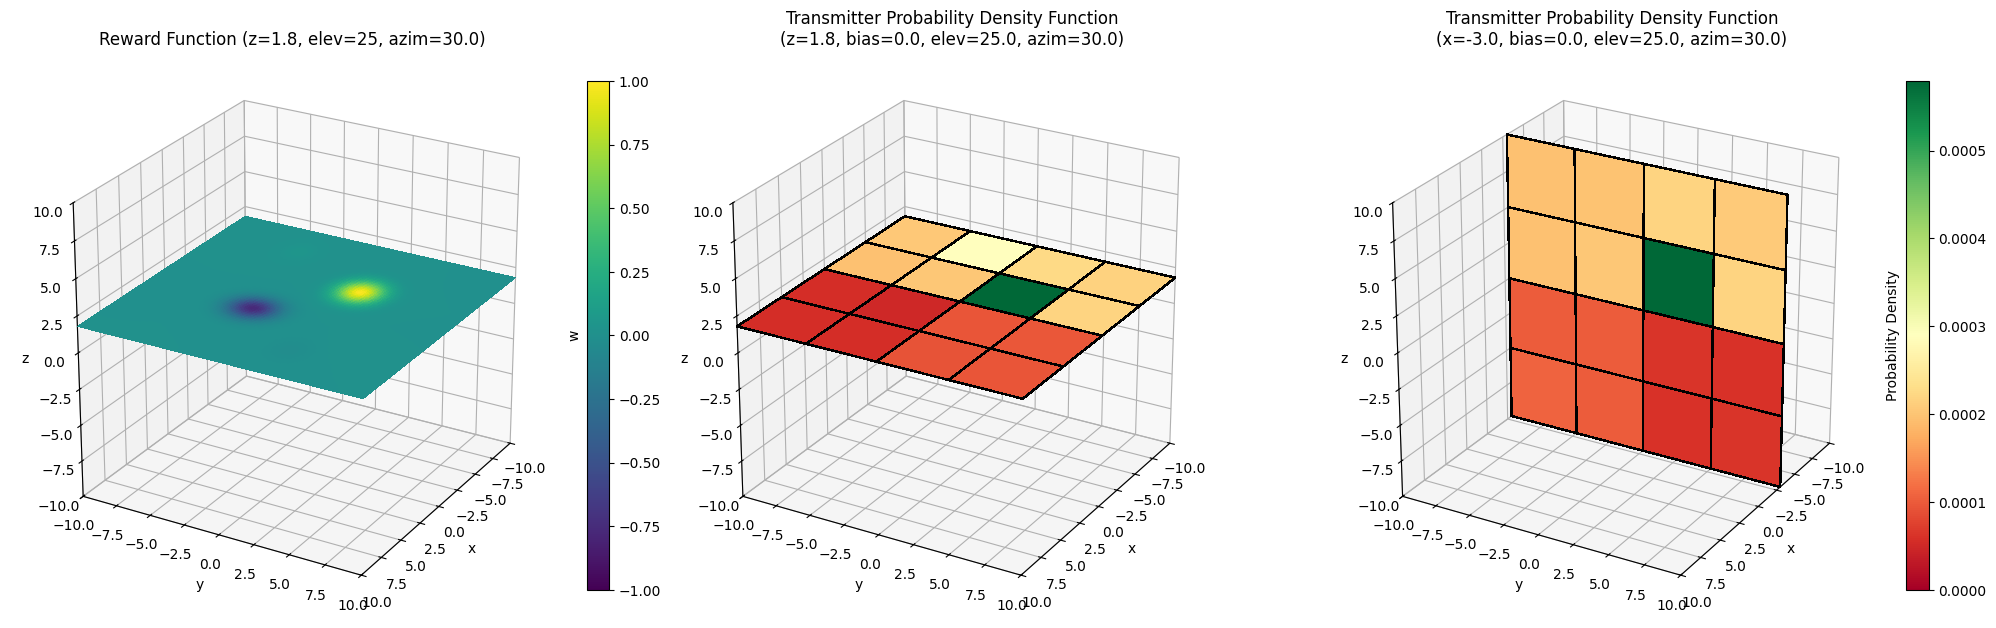

In [9]:
# set the transmitter plot steps
plot_steps = (
    {round(idx * (N_STEPS - 1) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    tsample = transmitter.forward(bias=0.0)
    reward = reward_function(
        tsample.coordinates[0], tsample.coordinates[1], tsample.coordinates[2]
    )
    transmitter.backward(tsample, reward)
    # plot the transmitter
    if step in plot_steps:
        fig, ax = plt.subplots(
            ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"}
        )
        plot_function(ax[0], reward_function, slice_ax="z", slice_val=1.8, elev=25)
        plot_transmitter(
            ax[1],
            transmitter,
            slice_ax="z",
            slice_val=1.8,
            bias=0.0,
            elev=25.0,
            colorbar=False,
        )
        plot_transmitter(
            ax[2], transmitter, slice_ax="x", slice_val=-3.0, bias=0.0, elev=25.0
        )
        # adjust the aspect ratio of each plot
        for axis in ax:
            axis.set_box_aspect((1, 1, 1), zoom=0.95)
        fig.tight_layout()
        plt.show()

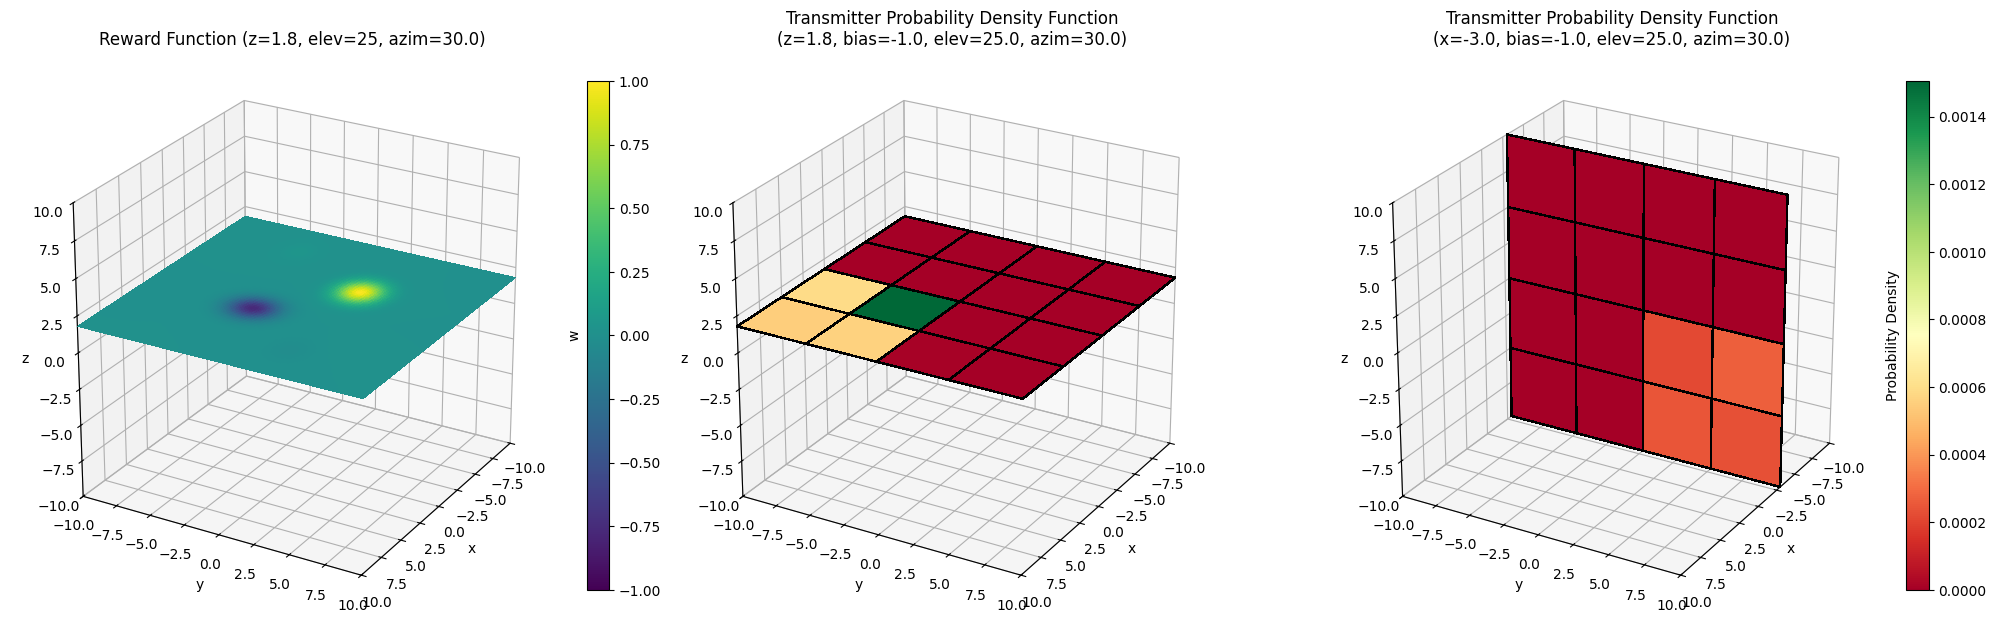

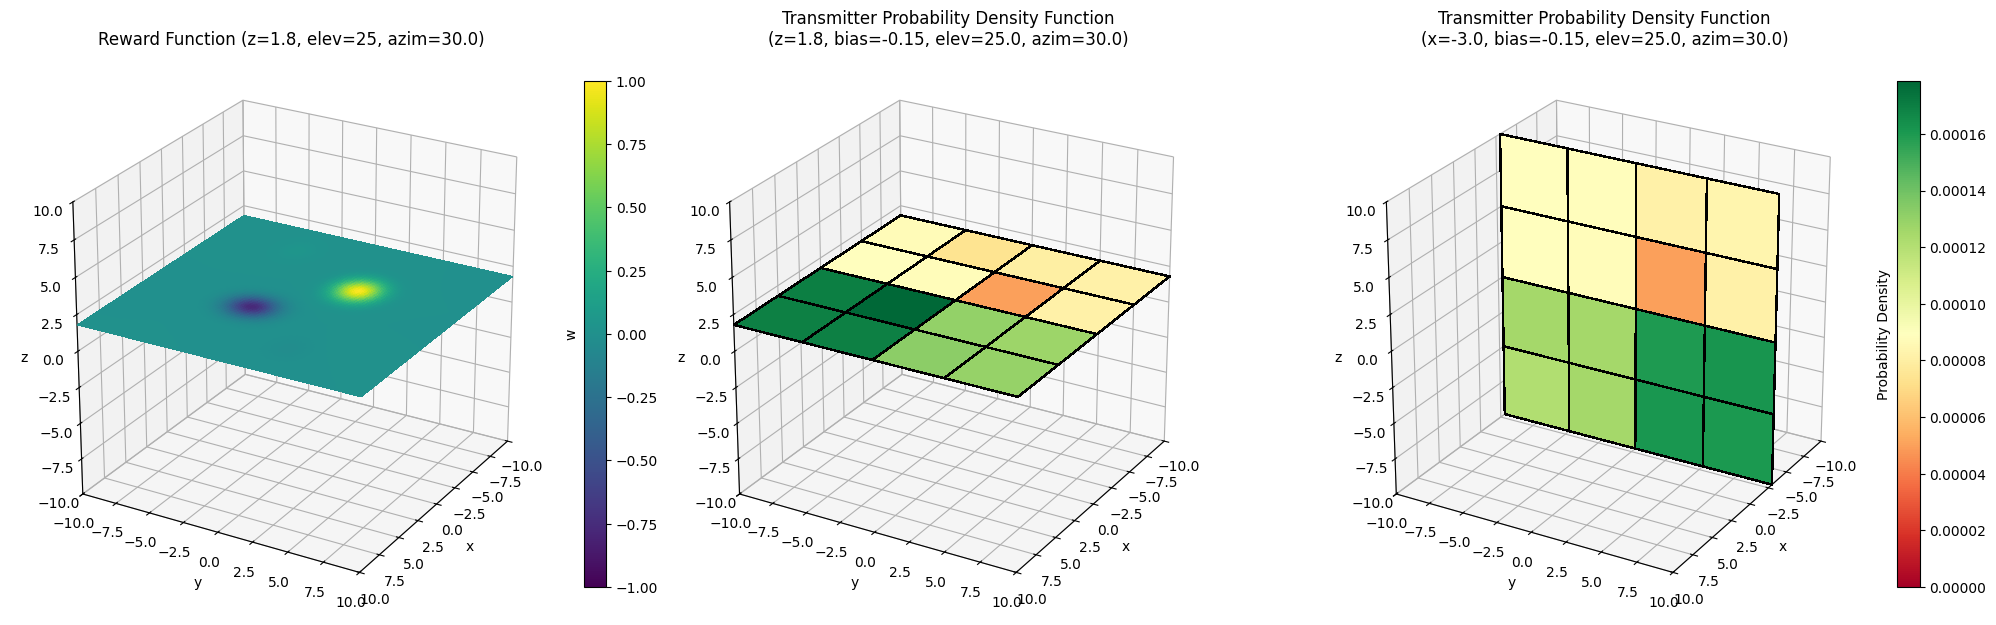

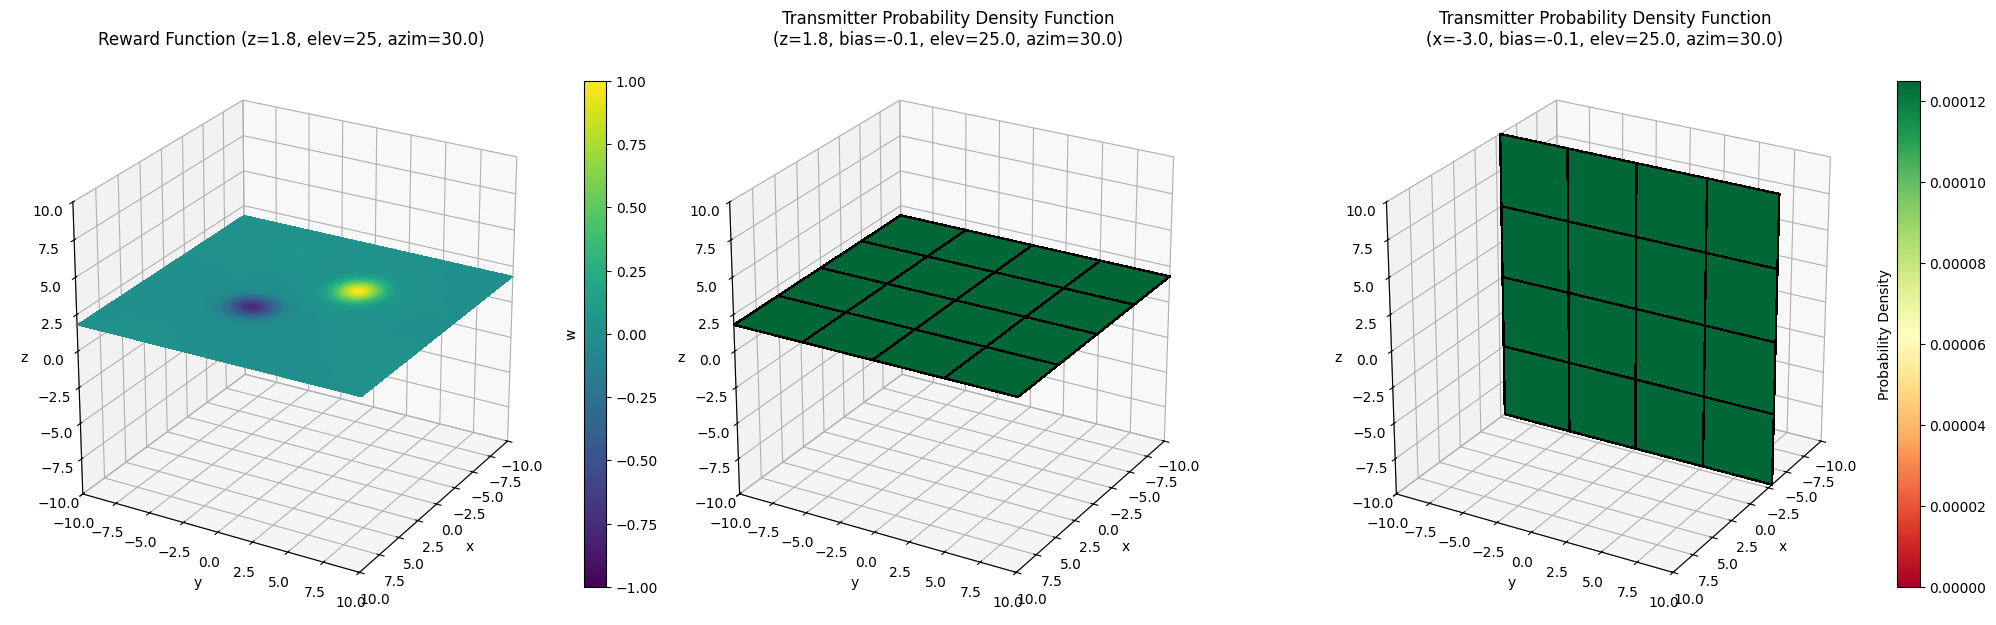

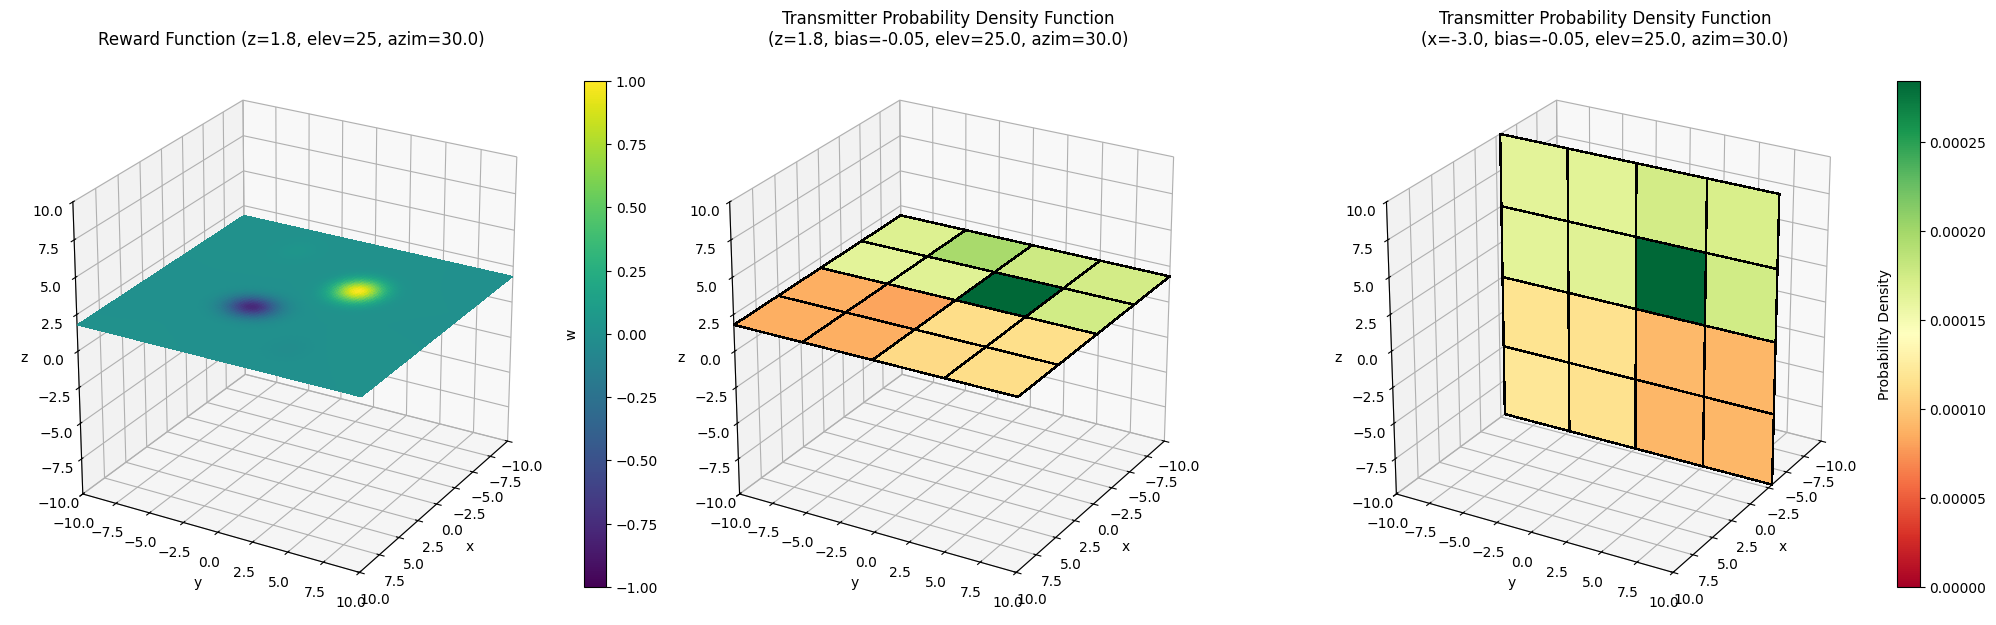

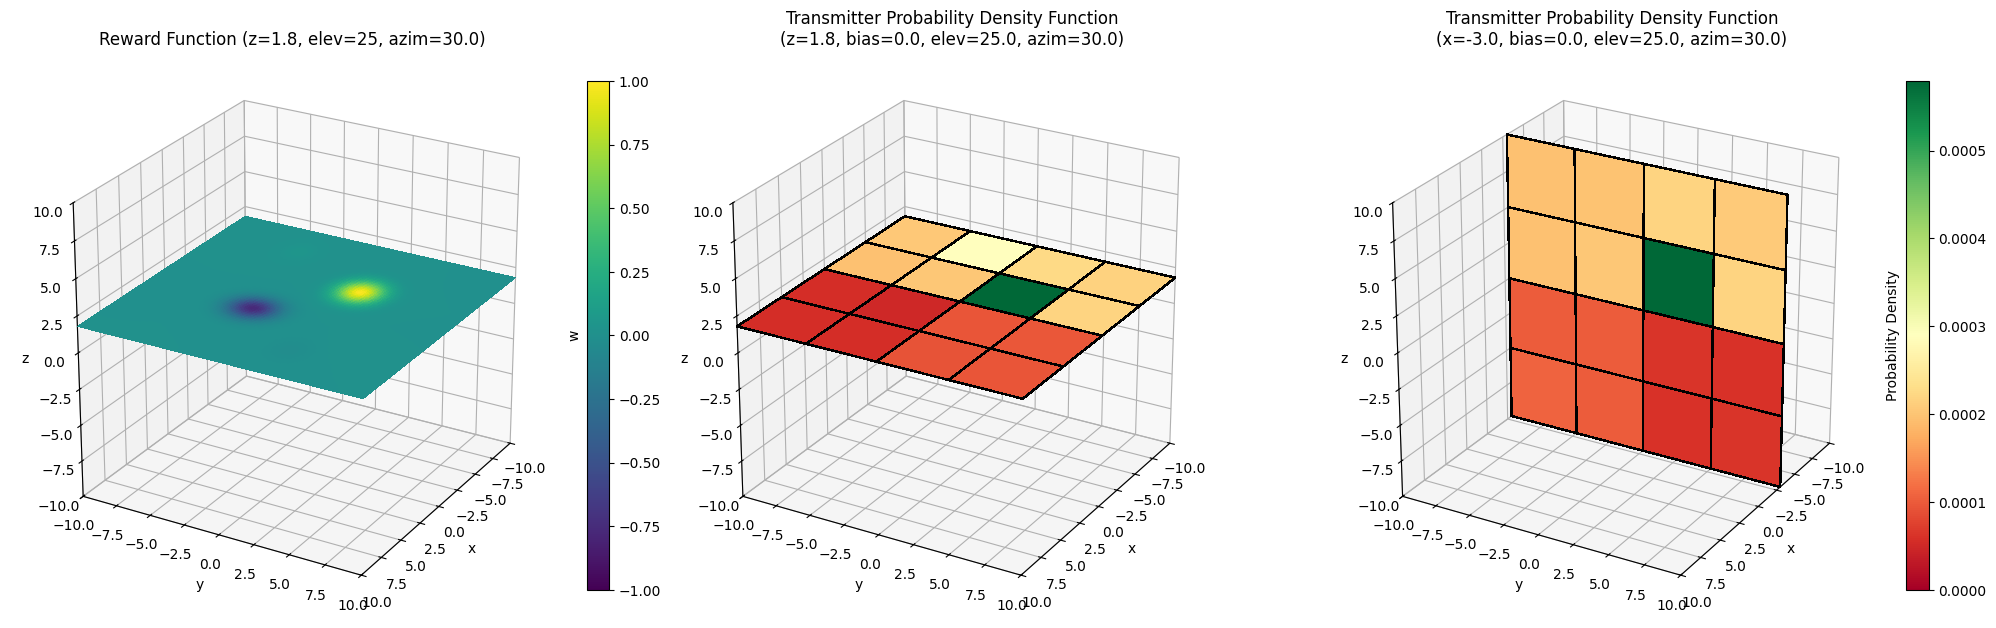

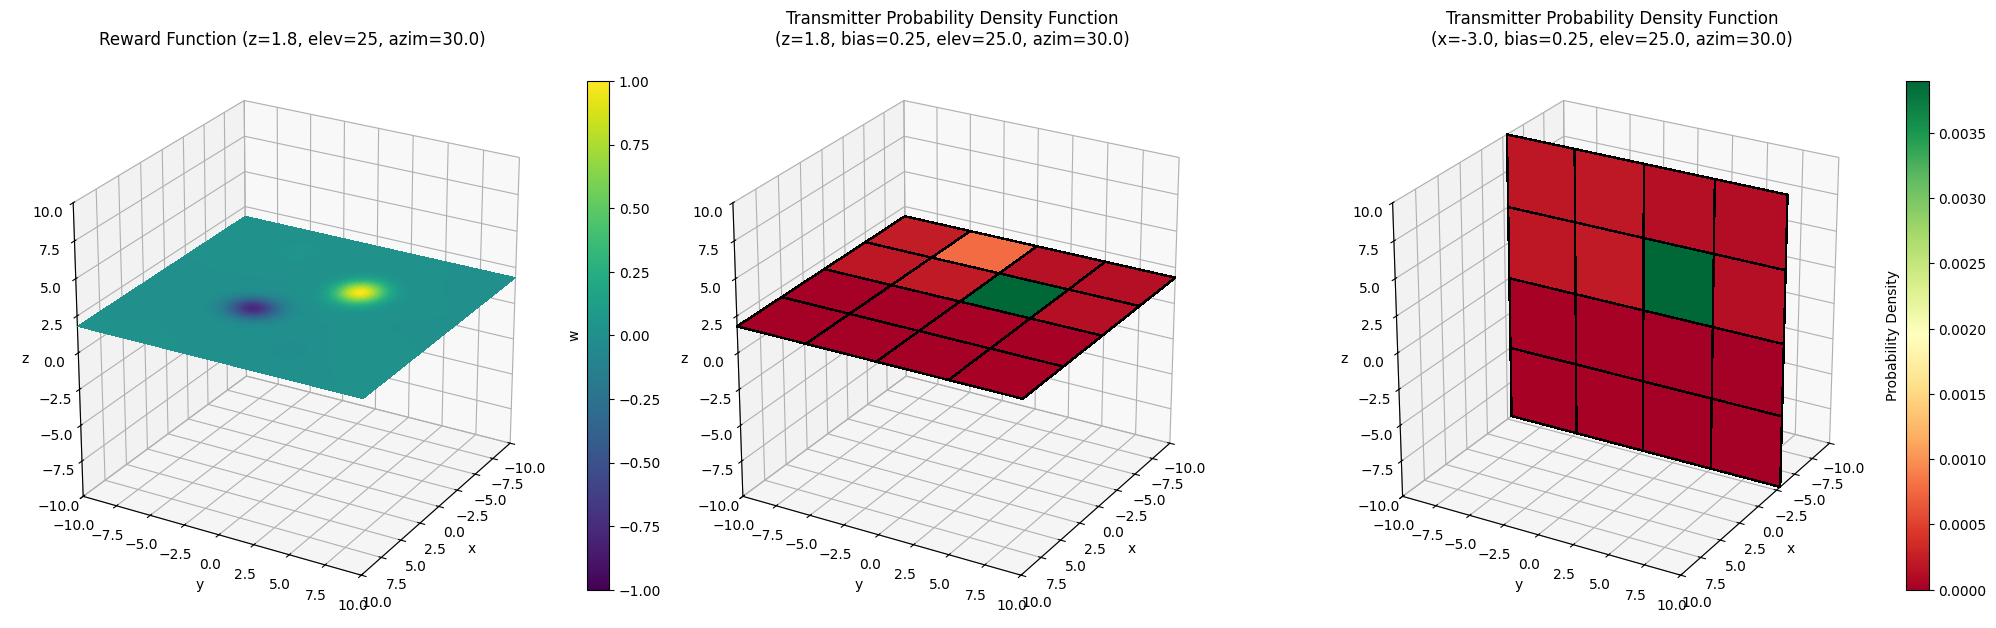

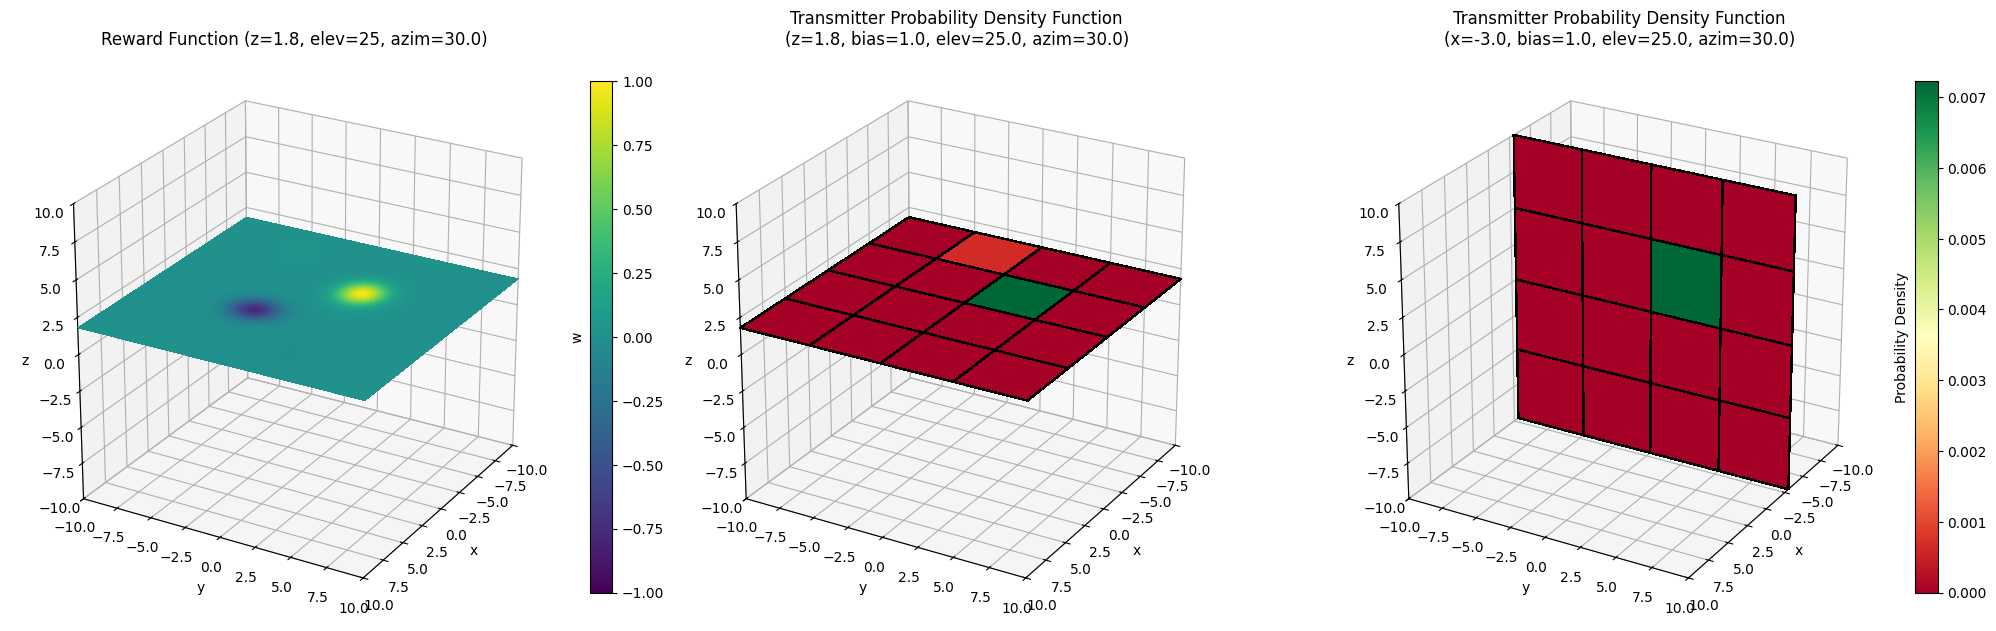

In [10]:
# define the list of biases to evaluate
biases = [-1.0, -0.15, -0.1, -0.05, 0.0, 0.25, 1.0]

# plot the transmitter for each bias
for bias in biases:
    fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
    plot_function(ax[0], reward_function, slice_ax="z", slice_val=1.8, elev=25)
    plot_transmitter(
        ax[1],
        transmitter,
        slice_ax="z",
        slice_val=1.8,
        bias=bias,
        elev=25.0,
        colorbar=False,
    )
    plot_transmitter(
        ax[2], transmitter, slice_ax="x", slice_val=-3.0, bias=bias, elev=25.0
    )
    # adjust the aspect ratio of each plot
    for axis in ax:
        axis.set_box_aspect((1, 1, 1), zoom=0.95)
    fig.tight_layout()
    plt.show()